In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [3]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 1
event_type = 'ttbar_pu200'
number_of_hf_repo_files= 1000
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

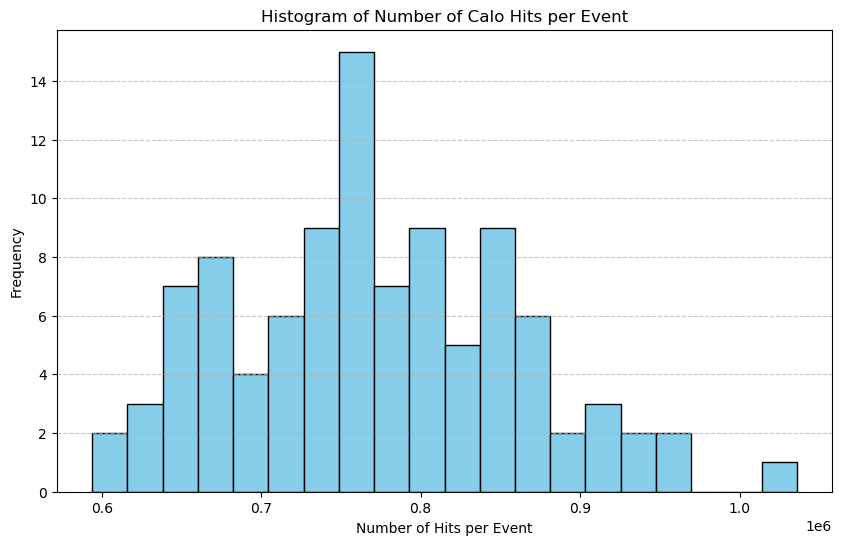

In [10]:
import matplotlib.pyplot as plt

# Compute the number of hits per event
num_hits_per_event = (
    calo_hits.select([
        "event_id",
        pl.col("detector").list.len().alias("n_hits")
    ])
    .group_by("event_id")
    .agg(pl.col("n_hits").sum())
    .get_column("n_hits")
    .to_numpy()
)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(num_hits_per_event, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Number of Hits per Event')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Calo Hits per Event')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [5]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv3
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles_copy = particles.clone()

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 9397289 depositors.


In [6]:
particles = set_target_particles_maskv3(particles, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.3)

Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [24]:
import matplotlib.pyplot as plt
import polars as pl

# Calculate number of particles per vertex_primary
particles_per_vertex = (
    particles.lazy()
    .select('vertex_primary', 'event_id')
    .explode('vertex_primary')
    .group_by('vertex_primary', 'event_id')
    .len()
    .collect()
)

# Compute averages for categories
avg_particles_gt1 = particles_per_vertex.filter(pl.col('vertex_primary') > 1)['len'].mean()
avg_particles_eq1 = particles_per_vertex.filter(pl.col('vertex_primary') == 1)['len'].mean()

# Create a DataFrame for display
averages = pl.DataFrame({
    'Category': ['vertex_primary > 1', 'vertex_primary == 1'],
    'Average Particles': [avg_particles_gt1, avg_particles_eq1]
})

print(averages)

shape: (2, 2)
┌─────────────────────┬───────────────────┐
│ Category            ┆ Average Particles │
│ ---                 ┆ ---               │
│ str                 ┆ f64               │
╞═════════════════════╪═══════════════════╡
│ vertex_primary > 1  ┆ 854.927233        │
│ vertex_primary == 1 ┆ 5231.93           │
└─────────────────────┴───────────────────┘


In [33]:
(particles.lazy()
    .select('vertex_primary', 'event_id', 'is_parent_missing')
    .explode('vertex_primary', 'is_parent_missing')
    .filter(pl.col('is_parent_missing') == True)
    ).collect()

vertex_primary,event_id,is_parent_missing
u16,u32,bool
1,26,true
1,26,true
1,26,true
1,26,true
1,26,true
…,…,…
211,90,true
211,90,true
211,90,true


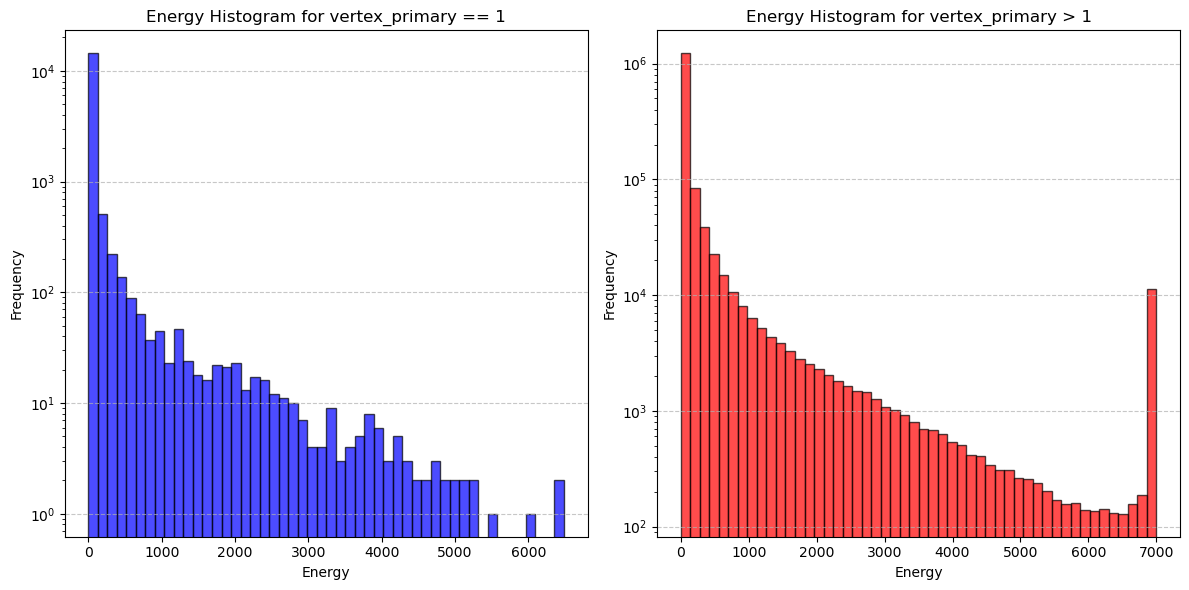

In [36]:
import matplotlib.pyplot as plt
import polars as pl

# Explode particles data to get per-particle energy and vertex_primary
exploded = (particles.lazy()
    .select('vertex_primary',  'is_parent_missing', 'energy')
    .explode('vertex_primary', 'is_parent_missing', 'energy')
    .filter(pl.col('is_parent_missing') == True)
    ).collect()
# Filter energies for vertex_primary == 1
energy_eq1 = exploded.filter(pl.col('vertex_primary') == 1)['energy']

# Filter energies for vertex_primary > 1
energy_gt1 = exploded.filter(pl.col('vertex_primary') > 1)['energy']

# Plot histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(energy_eq1, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Energy Histogram for vertex_primary == 1')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(energy_gt1, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('Energy Histogram for vertex_primary > 1')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')

plt.tight_layout()
plt.show()

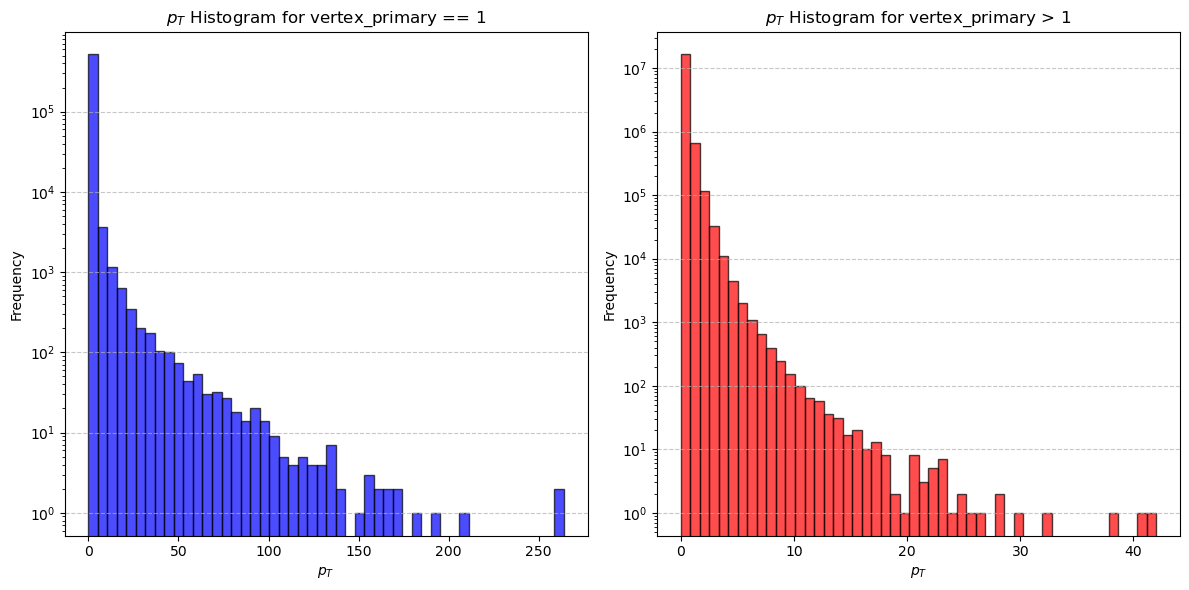

In [30]:
import matplotlib.pyplot as plt
import polars as pl

# Explode particles data to get per-particle energy and vertex_primary
exploded = (
    particles.lazy()
    .select('vertex_primary', 'pt')
    .explode('vertex_primary', 'pt')
    .collect()
)

# Filter energies for vertex_primary == 1
energy_eq1 = exploded.filter(pl.col('vertex_primary') == 1)['pt']

# Filter energies for vertex_primary > 1
energy_gt1 = exploded.filter(pl.col('vertex_primary') > 1)['pt']

# Plot histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(energy_eq1, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('$p_T$ Histogram for vertex_primary == 1')
plt.xlabel('$p_T$')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(energy_gt1, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title('$p_T$ Histogram for vertex_primary > 1')
plt.xlabel('$p_T$')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# log scale for y-axis
plt.yscale('log')

plt.tight_layout()
plt.show()

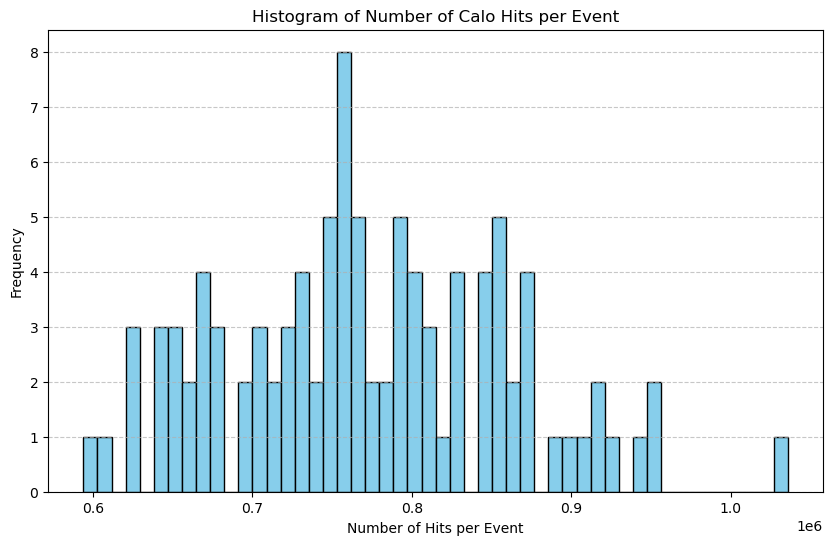

In [6]:
import matplotlib.pyplot as plt

# Since the schema uses list columns for each event, the number of hits is the length of these lists.
# We group by event_id and sum the lengths in case an event is split across multiple rows.
num_hits_per_event = (
    calo_hits.select([
        "event_id",
        pl.col("detector").list.len().alias("n_hits")
    ])
    .group_by("event_id")
    .agg(pl.col("n_hits").sum())
    .get_column("n_hits")
    .to_numpy()
)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(num_hits_per_event, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Number of Hits per Event')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Calo Hits per Event')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from primary.calibration import CALIBRATION
()

In [12]:
# bad config
from primary.interactive_plot import target_vs_truth_particles
target_vs_truth_particles(particles)

Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 11 iterations.
Step 4: Final validation...


    'data': [{'customdata': array([[  331.        ,  9261.1640625 ],
           …

In [9]:
from primary.preprocessing import add_ms_cluster_labels
calo = calo_hits.filter(pl.col("event_id") == 0)
calo = add_ms_cluster_labels(calo, bandwidth=120.0)

--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 1 events. Time: 0.02s
Workload optimized: 1 events merged into 1 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 179.65s


In [9]:
from primary.preprocessing import add_ms_cluster_labels_gpu
calo = calo_hits.filter(pl.col("event_id") == 0)
calo = add_ms_cluster_labels_gpu(calo, bandwidth=120.0)

--- Starting FAST GPU Clustering (Float32, MeanShift, bw=120.0) ---
Data prepared: 1 events. GPU Load Time: 0.04s


Processing Events:   0%|                                                                                                                 | 0/1 [01:37<?, ?it/s]


AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [8]:
import torch

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available")

GPU: NVIDIA RTX A5000


In [12]:
particles.select('vertex_primary')

vertex_primary
list[u16]
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"
…
"[1, 1, … 1]"
"[1, 1, … 1]"
"[1, 1, … 1]"


In [21]:
from primary.interactive_plot import  plot_calo_clusters_interactive
plot_calo_clusters_interactive(calo, particles=particles.filter(pl.col("event_id") == 0), event_idx=0)


FigureWidget({
    'data': [{'customdata': array([[1319, 3.114180922284504, 0.6927906868490061,
                                    '<b>π+</b> (PDG:211) ID:790: <b>0.7114 GeV</b><br><b>p</b> (PDG:2212) ID:184324: <b>0.3385 GeV</b><br><b>π+</b> (PDG:211) ID:184322: <b>0.2703 GeV</b><br><b>K+</b> (PDG:321) ID:65690: <b>0.2641 GeV</b><br><b>p</b> (PDG:2212) ID:184327: <b>0.1882 GeV</b>'],
                                   [134, 21.546630200055006, 0.8071673637403137,
                                    '<b>e+</b> (PDG:-11) ID:186933: <b>1.6113 GeV</b><br><b>e-</b> (PDG:11) ID:186956: <b>0.9139 GeV</b><br><b>e-</b> (PDG:11) ID:186957: <b>0.7856 GeV</b><br><b>e-</b> (PDG:11) ID:186952: <b>0.7546 GeV</b><br><b>e+</b> (PDG:-11) ID:186990: <b>0.7159 GeV</b>'],
                                   [3546, 0.5829869109293213, 0.5290858254705239,
                                    '<b>p</b> (PDG:2212) ID:185368: <b>0.1966 GeV</b><br><b>μ+</b> (PDG:-13) ID:170810: <b>0.113 GeV</b><br><b>p</b> (PDG:

event_id,ht_target,ht_truth
u32,f32,f32
10,3771.317871,3915.379639
19,2959.985596,3048.139404
35,3465.338867,3584.286865
69,3455.357666,3595.883545
12,2864.208252,2972.331543
…,…,…
32,3615.420898,3717.498047
84,2428.414307,2522.760742
44,3639.218018,3829.91626


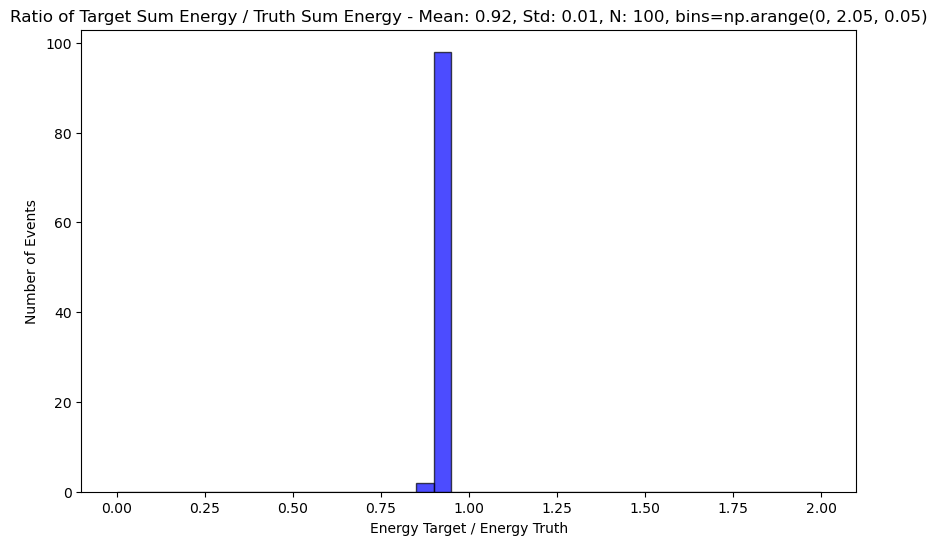

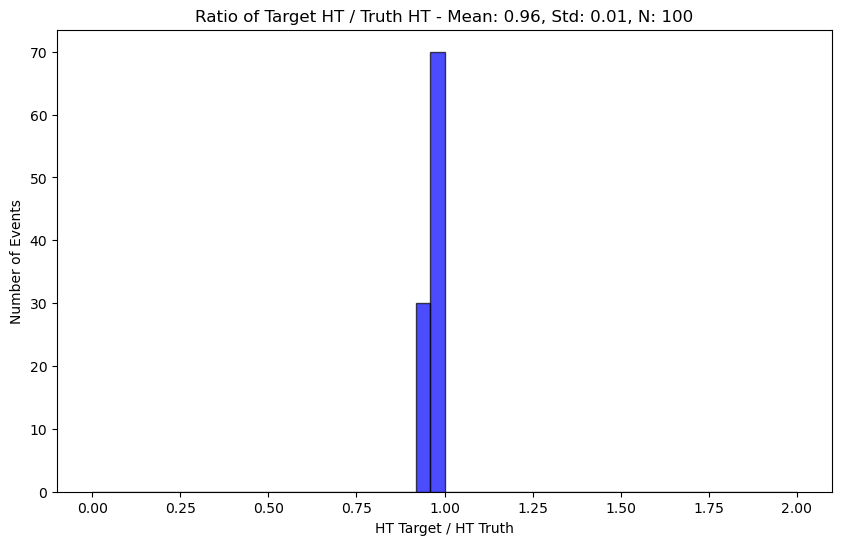

In [13]:
from primary.plot import histogram_ht_ratio,hist2d_ht_truth_vs_target, histogram_energy_ratio
histogram_energy_ratio(particles)
histogram_ht_ratio(particles)

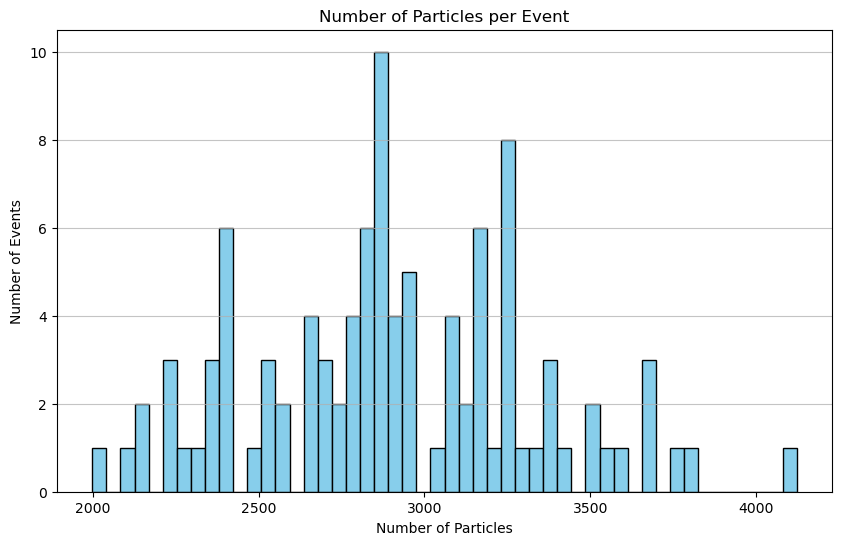

In [15]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = (
    particles.lazy()
    .select('event_id', 'particle_id', 'is_target_particle')
    .explode('particle_id', 'is_target_particle')
    .filter('is_target_particle')
    .group_by('event_id')
    .agg(pl.col('particle_id').count().alias('num_particles'))
    .collect()
)

plt.figure(figsize=(10, 6))
plt.hist(n_particles['num_particles'], bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()